In [1]:
using Plots
using LinearAlgebra

In [2]:
function nan_checker(list, str)
    for (index, contents) in enumerate(list)
        y = div(index, 260) + 1
        x = index % 260 + 1
        if isnan(contents)
            error("there is NaN at x = $x, y = $y, in " * str)
        elseif isinf(contents)
            error("there is inf at x = $x, y = $y, in " * str)
        end
    end
end

function fvm_checker(fvm, str)
    nan_checker(fvm.density, "fvm.density, " * str)
    nan_checker(fvm.momentum_x, "fvm.momentum_x, " * str)
    nan_checker(fvm.momentum_y, "fvm.momentum_y, " * str)
    nan_checker(fvm.ρE, "fvm.ρE, " * str)
    nan_checker(fvm._density, "fvm._density, " * str)
    nan_checker(fvm._momentum_x, "fvm._momentum_x, " * str)
    nan_checker(fvm._momentum_y, "fvm._momentum_y, " * str)
    nan_checker(fvm._ρE, "fvm._ρE, " * str)
    nan_checker(fvm.density_L, "fvm.density_L, " * str)
    nan_checker(fvm.density_R, "fvm.density_R, " * str)
    nan_checker(fvm.density_U, "fvm.density_U, " * str)
    nan_checker(fvm.density_B, "fvm.density_B, " * str)
    nan_checker(fvm.momentum_x_L, "fvm.momentum_x_L, " * str)
    nan_checker(fvm.momentum_x_R, "fvm.momentum_x_R, " * str)
    nan_checker(fvm.momentum_x_U, "fvm.momentum_x_U, " * str)
    nan_checker(fvm.momentum_x_B, "fvm.momentum_x_B, " * str)
    nan_checker(fvm.momentum_y_L, "fvm.momentum_y_L, " * str)
    nan_checker(fvm.momentum_y_R, "fvm.momentum_y_R, " * str)
    nan_checker(fvm.momentum_y_U, "fvm.momentum_y_U, " * str)
    nan_checker(fvm.momentum_y_B, "fvm.momentum_y_B, " * str)
    nan_checker(fvm.ρE_L, "fvm.ρE_L, " * str)
    nan_checker(fvm.ρE_R, "fvm.ρE_R, " * str)
    nan_checker(fvm.ρE_U, "fvm.ρE_U, " * str)
    nan_checker(fvm.ρE_B, "fvm.ρE_B, " * str)
    nan_checker(fvm.density_flux_horizontal, "fvm.density_flux_horizontal, " * str)
    nan_checker(fvm.momentum_x_flux_horizontal, "fvm.momentum_x_flux_horizontal, " * str)
    nan_checker(fvm.momentum_y_flux_horizontal, "fvm.momentum_y_flux_horizontal, " * str)
    nan_checker(fvm.ρE_flux_horizontal, "fvm.ρE_flux_horizontal, " * str)
    nan_checker(fvm.density_flux_vertical, "fvm.density_flux_vertical, " * str)
    nan_checker(fvm.momentum_x_flux_vertical, "fvm.momentum_x_flux_vertical, " * str)
    nan_checker(fvm.momentum_y_flux_vertical, "fvm.momentum_y_flux_vertical, " * str)
    nan_checker(fvm.ρE_flux_vertical, "fvm.ρE_flux_vertical, " * str)
    nan_checker(fvm._density_flux, "fvm._density_flux, " * str)
    nan_checker(fvm._momentum_x_flux, "fvm._momentum_x_flux, " * str)
    nan_checker(fvm._momentum_y_flux, "fvm._momentum_y_flux, " * str)
    nan_checker(fvm._ρE_flux, "fvm._ρE_flux, " * str)
end

function nan_desuka(var, str; showlist=[])
    if isnan(var)
        println(showlist)
        error("there is NaN in " * str)
    elseif isinf(var)
        println(showlist)
        error("there is inf in " * str)
    end
end

function root_checker(var, str; showlist=[])
    if var < 0.0
        println(showlist)
        println("warning: var = $var: is negative / in " * str)
    elseif var < 0.000000001
        println(showlist)
        println("warning: var = $var: too small / in " * str)
    end
end

root_checker (generic function with 1 method)

In [3]:
mutable struct FVM
    # grid parameters
    X_cells::Int
    Y_cells::Int
    X_max::Int
    Y_max::Int
    X_left::Float64
    X_right::Float64
    Y_bottom::Float64
    Y_up::Float64
    dx::Float64
    dy::Float64
    coordinate

    # time parameters
    dt::Float64         # time step width
    t::Float64          # time
    step_counter::Int
    maximal_velocity_x::Float64
    maximal_velocity_y::Float64

    # hyper parameter
    cfl::Float64        # CFL number: 0 < cfl < 1

    # physical parameter
    γ::Float64          # heat capacity ratio of ideal gas

    # mean value of cells
    density
    momentum_x
    momentum_y
    ρE

    # value of cells (reservor)
    _density
    _momentum_x
    _momentum_y
    _ρE

    # values of cell boundary
    density_L
    density_R
    density_U
    density_B
    momentum_x_L
    momentum_x_R
    momentum_x_U
    momentum_x_B
    momentum_y_L
    momentum_y_R
    momentum_y_U
    momentum_y_B
    ρE_L
    ρE_R
    ρE_U
    ρE_B

    # numerical flux of cell boundaries
    density_flux_horizontal
    momentum_x_flux_horizontal
    momentum_y_flux_horizontal
    ρE_flux_horizontal
    density_flux_vertical
    momentum_x_flux_vertical
    momentum_y_flux_vertical
    ρE_flux_vertical

    # flux (reservor)
    _density_flux
    _momentum_x_flux
    _momentum_y_flux
    _ρE_flux

    # constructor
    function FVM(density_init, pressure_init, velocity_x_init, velocity_y_init;
                 X_cells=256, Y_cells=80, X_left=0.0, X_right=3.2, Y_bottom=0.0, Y_up=1.0, γ=1.4, cfl=0.2)
        t = 0.0
        dt = 0.0
        step_counter = 0
        X_max = X_cells + 2 * 2
        Y_max = Y_cells + 2 * 2
        dx = (X_right - X_left) / X_cells
        dy = (Y_up - Y_bottom) / Y_cells
        coordinate = [(x = X_left + i * dx, y = Y_bottom + j * dy) for i = -2 : X_cells + 1, j = -2 : Y_cells + 1]
        maximal_velocity_x = 0.1
        maximal_velocity_y = 0.1

        density = density_init.(coordinate)
        pressure = pressure_init.(coordinate)
        velocity_x = velocity_x_init.(coordinate)
        velocity_y = velocity_y_init.(coordinate)
        momentum_x = density .* velocity_x      # product by component
        momentum_y = density .* velocity_y
        ρE =  0.5 .* density .* (velocity_x .* velocity_x .+ velocity_y .* velocity_y) + pressure ./ (γ - 1.0)

        _density = zeros(X_max, Y_max)
        _momentum_x = zeros(X_max, Y_max)
        _momentum_y = zeros(X_max, Y_max)
        _ρE = zeros(X_max, Y_max)
        density_L = zeros(X_max + 1, Y_max + 1)
        density_R = zeros(X_max + 1, Y_max + 1)
        density_U = zeros(X_max + 1, Y_max + 1)
        density_B = zeros(X_max + 1, Y_max + 1)
        momentum_x_L = zeros(X_max + 1, Y_max + 1)
        momentum_x_R = zeros(X_max + 1, Y_max + 1)
        momentum_x_U = zeros(X_max + 1, Y_max + 1)
        momentum_x_B = zeros(X_max + 1, Y_max + 1)
        momentum_y_L = zeros(X_max + 1, Y_max + 1)
        momentum_y_R = zeros(X_max + 1, Y_max + 1)
        momentum_y_U = zeros(X_max + 1, Y_max + 1)
        momentum_y_B = zeros(X_max + 1, Y_max + 1)
        ρE_L = zeros(X_max + 1, Y_max + 1)
        ρE_R = zeros(X_max + 1, Y_max + 1)
        ρE_U = zeros(X_max + 1, Y_max + 1)
        ρE_B = zeros(X_max + 1, Y_max + 1)
        density_flux_horizontal = zeros(X_max + 1, Y_max + 1)
        momentum_x_flux_horizontal = zeros(X_max + 1, Y_max + 1)
        momentum_y_flux_horizontal = zeros(X_max + 1, Y_max + 1)
        ρE_flux_horizontal = zeros(X_max + 1, Y_max + 1)
        density_flux_vertical = zeros(X_max + 1, Y_max + 1)
        momentum_x_flux_vertical = zeros(X_max + 1, Y_max + 1)
        momentum_y_flux_vertical = zeros(X_max + 1, Y_max + 1)
        ρE_flux_vertical = zeros(X_max + 1, Y_max + 1)
        _density_flux = zeros(X_max + 1, Y_max + 1)
        _momentum_x_flux = zeros(X_max + 1, Y_max + 1)
        _momentum_y_flux = zeros(X_max + 1, Y_max + 1)
        _ρE_flux = zeros(X_max + 1, Y_max + 1)
        new(X_cells, Y_cells, X_max, Y_max, X_left, X_right, Y_bottom, Y_up, dx, dy, coordinate, dt, t, step_counter, maximal_velocity_x, maximal_velocity_y, cfl, γ,
            density, momentum_x, momentum_y, ρE, _density, _momentum_x, _momentum_y, _ρE,
            density_L, density_R, density_U, density_B, momentum_x_L, momentum_x_R, momentum_x_U, momentum_x_B, momentum_y_L, momentum_y_R, momentum_y_U, momentum_y_B, ρE_L, ρE_R, ρE_U, ρE_B,
            density_flux_horizontal, momentum_x_flux_horizontal, momentum_y_flux_horizontal, ρE_flux_horizontal, density_flux_vertical, momentum_x_flux_vertical, momentum_y_flux_vertical, ρE_flux_vertical,
            _density_flux, _momentum_x_flux, _momentum_y_flux, _ρE_flux)
    end
end

function show_settings(fvm)
    println("X_cells = $(fvm.X_cells), Y_cells = $(fvm.Y_cells)\n[X_left, X_right] = [$(fvm.X_left), $(fvm.X_right)], [Y_bottom, Y_up] = [$(fvm.Y_bottom), $(fvm.Y_up)]")
    println("dx = $(fvm.dx), dy = $(fvm.dy)\nCFL number = $(fvm.cfl), heat capacity ratio of ideal gas = $(fvm.γ)\n")
end

function show_parameters(fvm)
    println("########## step $(fvm.step_counter) ##########")
    println("dt = $(fvm.dt) t = $(fvm.t)\n")
end

# main loop
function solve!(fvm, t_stop)
    show_settings(fvm)
    while fvm.t <= t_stop
        boundary_condition!(fvm)
        reconstruction_x!(fvm)
        reconstruction_y!(fvm)
        flux_difference_splitting!(fvm, "x")
        flux_difference_splitting!(fvm, "y")
        dt_update!(fvm)
        Runge_Kutta_first!(fvm)
        boundary_condition!(fvm)
        reconstruction_x!(fvm)
        reconstruction_y!(fvm)
        flux_difference_splitting!(fvm, "x")
        flux_difference_splitting!(fvm, "y")
        dt_update!(fvm)
        Runge_Kutta_second!(fvm)
        fvm.t += fvm.dt
        fvm.step_counter += 1

        if fvm.step_counter % 100 == 0
            show_parameters(fvm)
        end
    end
    println("<calculation finished>")
    show_parameters(fvm)
end

# spacial reconstruction: van Leer limitor
function reconstruction_x!(fvm)
    for i = 2 : fvm.X_cells + 2
        for j = 3 : fvm.Y_cells + 3
            fvm.density_L[i+1, j] = fvm.density[i, j] + 0.5 * (fvm.density[i+1, j] - fvm.density[i, j]) * _limitor(i, j, fvm.density, "left")
            fvm.density_R[i+1, j] = fvm.density[i+1, j] - 0.5 * (fvm.density[i+1, j] - fvm.density[i, j]) * _limitor(i, j, fvm.density, "right")
            fvm.momentum_x_L[i+1, j] = fvm.momentum_x[i, j] + 0.5 * (fvm.momentum_x[i+1, j] - fvm.momentum_x[i, j]) * _limitor(i, j, fvm.momentum_x, "left")
            fvm.momentum_x_R[i+1, j] = fvm.momentum_x[i+1, j] - 0.5 * (fvm.momentum_x[i+1, j] - fvm.momentum_x[i, j]) * _limitor(i, j, fvm.momentum_x, "right")
            fvm.momentum_y_L[i+1, j] = fvm.momentum_y[i, j] + 0.5 * (fvm.momentum_y[i+1, j] - fvm.momentum_y[i, j]) * _limitor(i, j, fvm.momentum_y, "left")
            fvm.momentum_y_R[i+1, j] = fvm.momentum_y[i+1, j] - 0.5 * (fvm.momentum_y[i+1, j] - fvm.momentum_y[i, j]) * _limitor(i, j, fvm.momentum_y, "right")
            fvm.ρE_L[i+1, j] = fvm.ρE[i, j] + 0.5 * (fvm.ρE[i+1, j] - fvm.ρE[i, j]) * _limitor(i, j, fvm.ρE, "left")
            fvm.ρE_R[i+1, j] = fvm.ρE[i+1, j] - 0.5 * (fvm.ρE[i+1, j] - fvm.ρE[i, j]) * _limitor(i, j, fvm.ρE, "right")
        end
    end
end

function reconstruction_y!(fvm)
    for j = 2 : fvm.Y_cells + 2
        for i = 3 : fvm.X_cells + 3
            fvm.density_B[i, j+1] = fvm.density[i, j] + 0.5 * (fvm.density[i, j+1] - fvm.density[i, j]) * _limitor(i, j, fvm.density, "bottom")
            fvm.density_U[i, j+1] = fvm.density[i, j+1] - 0.5 * (fvm.density[i, j+1] - fvm.density[i, j]) * _limitor(i, j, fvm.density, "up")
            fvm.momentum_x_B[i, j+1] = fvm.momentum_x[i, j] + 0.5 * (fvm.momentum_x[i, j+1] - fvm.momentum_x[i, j]) * _limitor(i, j, fvm.momentum_x, "bottom")
            fvm.momentum_x_U[i, j+1] = fvm.momentum_x[i, j+1] - 0.5 * (fvm.momentum_x[i, j+1] - fvm.momentum_x[i, j]) * _limitor(i, j, fvm.momentum_x, "up")
            fvm.momentum_y_B[i, j+1] = fvm.momentum_y[i, j] + 0.5 * (fvm.momentum_y[i, j+1] - fvm.momentum_y[i, j]) * _limitor(i, j, fvm.momentum_y, "bottom")
            fvm.momentum_y_U[i, j+1] = fvm.momentum_y[i, j+1] - 0.5 * (fvm.momentum_y[i, j+1] - fvm.momentum_y[i, j]) * _limitor(i, j, fvm.momentum_y, "up")
            fvm.ρE_B[i, j+1] = fvm.ρE[i, j] + 0.5 * (fvm.ρE[i, j+1] - fvm.ρE[i, j]) * _limitor(i, j, fvm.ρE, "bottom")
            fvm.ρE_U[i, j+1] = fvm.ρE[i, j+1] - 0.5 * (fvm.ρE[i, j+1] - fvm.ρE[i, j]) * _limitor(i, j, fvm.ρE, "up")
        end
    end
end

function _limitor(i, j, var, _direction; ϵ=0.00000001)
    # van Leer limitor
    limitor = (x -> (x + abs(x)) / (1.0 + abs(x)))

    if _direction == "left"
        numerator = var[i, j] - var[i-1, j]
        denominator = var[i+1, j] - var[i, j]
    elseif _direction == "right"
        numerator = var[i+2, j] - var[i+1, j]
        denominator = var[i+1, j] - var[i, j]
    elseif _direction == "bottom"
        numerator = var[i, j] - var[i, j-1]
        denominator = var[i, j+1] - var[i, j]
    elseif _direction == "up"
        numerator = var[i, j+2] - var[i, j+1]
        denominator = var[i, j+1] - var[i, j]
    end

    if abs(denominator) < ϵ
        if denominator < 0.0
            denominator = -ϵ
        else
            denominator = ϵ
        end
    end

    return limitor(numerator / denominator)
end

# Roe-Harten Riemann solver
function flux_difference_splitting!(fvm, direction; ϵ=0.15)        # ϵ: Harten's parameter
    Harten_modification = (λ -> abs(λ) < 2.0 * ϵ ? λ^2 / (4.0 * ϵ) + ϵ : abs(λ))

    velocity_max = 0.1      # minimal value for numerical stability
    for i = 3 : fvm.X_cells + 3, j = 3 : fvm.Y_cells + 3
        # primitive variables
        if direction == "x"
            d_prev = fvm.density_L[i, j]
            d_next = fvm.density_R[i, j]
            m_x_prev = fvm.momentum_x_L[i, j]
            m_x_next = fvm.momentum_x_R[i, j]
            m_y_prev = fvm.momentum_y_L[i, j]
            m_y_next = fvm.momentum_y_R[i, j]
            E_prev = fvm.ρE_L[i, j]
            E_next = fvm.ρE_R[i, j]
        elseif direction == "y"
            d_prev = fvm.density_B[i, j]
            d_next = fvm.density_U[i, j]
            m_x_prev = fvm.momentum_x_B[i, j]
            m_x_next = fvm.momentum_x_U[i, j]
            m_y_prev = fvm.momentum_y_B[i, j]
            m_y_next = fvm.momentum_y_U[i, j]
            E_prev = fvm.ρE_B[i, j]
            E_next = fvm.ρE_U[i, j]
        end

        v_x_prev = m_x_prev / d_prev
        v_x_next = m_x_next / d_next
        v_y_prev = m_y_prev / d_prev
        v_y_next = m_y_next / d_next
        p_prev = (fvm.γ - 1.0) * (E_prev - 0.5 * d_prev * (v_x_prev ^ 2 + v_y_prev ^ 2))
        p_next = (fvm.γ - 1.0) * (E_next - 0.5 * d_next * (v_x_next ^ 2 + v_y_next ^ 2))
        H_prev = (E_prev + p_prev) / d_prev
        H_next = (E_next + p_next) / d_next

        # Roe average
        d_prev_sqrt = sqrt(d_prev)
        d_next_sqrt = sqrt(d_next)
        d_avg = d_prev_sqrt * d_next_sqrt
        v_x_avg = (v_x_prev * d_prev_sqrt + v_x_next * d_next_sqrt) / (d_prev_sqrt + d_next_sqrt)
        v_y_avg = (v_y_prev * d_prev_sqrt + v_y_next * d_next_sqrt) / (d_prev_sqrt + d_next_sqrt)
        H_avg = (H_prev * d_prev_sqrt + H_next * d_next_sqrt) / (d_prev_sqrt + d_next_sqrt)
        c_avg = sqrt((fvm.γ - 1.0) * (H_avg - 0.5 * (v_x_avg ^ 2 + v_y_avg ^ 2)))
        K_avg = 0.5 * (v_x_avg ^ 2 + v_y_avg ^ 2)

        # flux
        if direction == "x"
            λ1 = Harten_modification(v_x_avg)
            λ2 = λ1
            λ3 = Harten_modification(v_x_avg + c_avg)
            λ4 = Harten_modification(v_x_avg - c_avg)

            dw1 = (d_next - d_prev) - (p_next - p_prev) / c_avg ^ 2
            dw2 = v_y_prev - v_y_next
            dw3 = (v_x_next - v_x_prev) + (p_next - p_prev) / (d_avg * c_avg)
            dw4 = (v_x_next - v_x_prev) - (p_next - p_prev) / (d_avg * c_avg)

            f1 = m_x_next + m_x_prev
            f1 -= λ1 * dw1
            f1 -= λ3 * dw3 * d_avg / (2.0 * c_avg)
            f1 += λ4 * dw4 * d_avg / (2.0 * c_avg)
            fvm.density_flux_horizontal[i, j] = 0.5 * f1

            f2 = (fvm.γ - 1.0) * E_next + 0.5 * ((3.0 - fvm.γ) * m_x_next * v_x_next - (fvm.γ - 1.0) * m_y_next * v_y_next)
            f2 += (fvm.γ - 1.0) * E_prev + 0.5 * ((3.0 - fvm.γ) * m_x_prev * v_x_prev - (fvm.γ - 1.0) * m_y_prev * v_y_prev)
            f2 -= λ1 * dw1 * v_x_avg
            f2 -= λ3 * dw3 * 0.5 * d_avg * (v_x_avg / c_avg + 1.0)
            f2 += λ4 * dw4 * 0.5 * d_avg * (v_x_avg / c_avg - 1.0)
            fvm.momentum_x_flux_horizontal[i, j] = 0.5 * f2

            f3 = m_x_next * v_y_next + m_x_prev * v_y_prev
            f3 -= λ1 * dw1 * v_y_avg
            f3 += λ2 * dw2 * d_avg
            f3 -= λ3 * dw3 * d_avg * v_y_avg / (2.0 * c_avg)
            f3 += λ4 * dw4 * d_avg * v_y_avg / (2.0 * c_avg)
            fvm.momentum_y_flux_horizontal[i, j] = 0.5 * f3

            f4 = fvm.γ * E_next * v_x_next - (fvm.γ - 1.0) * 0.5 * m_x_next * (v_x_next ^ 2 + v_y_next ^ 2)
            f4 += fvm.γ * E_prev * v_x_prev - (fvm.γ - 1.0) * 0.5 * m_x_prev * (v_x_prev ^ 2 + v_y_prev ^ 2)
            f4 -= λ1 * dw1 * K_avg
            f4 += λ2 * dw2 * d_avg * v_y_avg
            f4 -= λ3 * dw3 * d_avg / (2.0 * c_avg) * (K_avg + c_avg ^ 2 / (fvm.γ - 1.0) + c_avg * v_x_avg)
            f4 += λ4 * dw4 * d_avg / (2.0 * c_avg) * (K_avg + c_avg ^ 2 / (fvm.γ - 1.0) - c_avg * v_x_avg)
            fvm.ρE_flux_horizontal[i, j] = 0.5 * f4
        elseif direction == "y"
            λ1 = Harten_modification(v_y_avg)
            λ2 = λ1
            λ3 = Harten_modification(v_y_avg + c_avg)
            λ4 = Harten_modification(v_y_avg - c_avg)

            dw1 = (d_next - d_prev) - (p_next - p_prev) / c_avg ^ 2
            dw2 = v_x_next - v_x_prev
            dw3 = (v_y_next - v_y_prev) + (p_next - p_prev) / (d_avg * c_avg)
            dw4 = (v_y_next - v_y_prev) - (p_next - p_prev) / (d_avg * c_avg)

            g1 = m_y_next + m_y_prev
            g1 -= λ1 * dw1
            g1 -= λ3 * dw3 * d_avg / (2.0 * c_avg)
            g1 += λ4 * dw4 * d_avg / (2.0 * c_avg)
            fvm.density_flux_vertical[i, j] = 0.5 * g1

            g2 = m_x_next * v_y_next + m_x_prev * v_y_prev
            g2 -= λ1 * dw1 * v_x_avg
            g2 -= λ2 * dw2 * d_avg
            g2 -= λ3 * dw3 * d_avg * v_x_avg / (2.0 * c_avg)
            g2 += λ4 * dw4 * d_avg * v_x_avg / (2.0 * c_avg)
            fvm.momentum_x_flux_vertical[i, j] = 0.5 * g2

            g3 = (fvm.γ - 1.0) * E_next + 0.5 * ((3.0 - fvm.γ) * m_y_next * v_y_next - (fvm.γ - 1.0) * m_x_next * v_x_next)
            g3 += (fvm.γ - 1.0) * E_prev + 0.5 * ((3.0 - fvm.γ) * m_y_prev * v_y_prev - (fvm.γ - 1.0) * m_x_prev * v_x_prev)
            g3 -= λ1 * dw1 * v_y_avg
            g3 -= λ3 * dw3 * 0.5 * d_avg * (v_y_avg / c_avg + 1.0)
            g3 += λ4 * dw4 * 0.5 * d_avg * (v_y_avg / c_avg - 1.0)
            fvm.momentum_y_flux_vertical[i, j] = 0.5 * g3

            g4 = fvm.γ * E_next * v_y_next - (fvm.γ - 1.0) * 0.5 * m_y_next * (v_x_next ^ 2 + v_y_next ^ 2)
            g4 += fvm.γ * E_prev * v_y_prev - (fvm.γ - 1.0) * 0.5 * m_y_prev * (v_x_prev ^ 2 + v_y_prev ^ 2)
            g4 -= λ1 * dw1 * K_avg
            g4 -= λ2 * dw2 * d_avg * v_x_avg
            g4 -= λ3 * dw3 * d_avg / (2.0 * c_avg) * (K_avg + c_avg ^ 2 / (fvm.γ - 1.0) + c_avg * v_y_avg)
            g4 += λ4 * dw4 * d_avg / (2.0 * c_avg) * (K_avg + c_avg ^ 2 / (fvm.γ - 1.0) - c_avg * v_y_avg)
            fvm.ρE_flux_vertical[i, j] = 0.5 * g4
        end

        velocity_max = max(λ3, λ4, velocity_max)
    end

    if direction == "x"
        fvm.maximal_velocity_x = velocity_max
    elseif direction == "y"
        fvm.maximal_velocity_y = velocity_max
    end
end

function Runge_Kutta_first!(fvm)
    for i = 3 : fvm.X_cells + 2
        for j = 3 : fvm.Y_cells + 2
            fvm._density[i, j] = fvm.density[i, j]
            fvm._momentum_x[i, j] = fvm.momentum_x[i, j]
            fvm._momentum_y[i, j] = fvm.momentum_y[i, j]
            fvm._ρE[i, j] = fvm.ρE[i, j]

            fvm._density_flux[i, j] = (fvm.density_flux_horizontal[i, j] - fvm.density_flux_horizontal[i+1, j]) / fvm.dx + (fvm.density_flux_vertical[i, j] - fvm.density_flux_vertical[i, j+1]) / fvm.dy
            fvm._momentum_x_flux[i, j] = (fvm.momentum_x_flux_horizontal[i, j] - fvm.momentum_x_flux_horizontal[i+1, j]) / fvm.dx + (fvm.momentum_x_flux_vertical[i, j] - fvm.momentum_x_flux_vertical[i, j+1]) / fvm.dy
            fvm._momentum_y_flux[i, j] = (fvm.momentum_y_flux_horizontal[i, j] - fvm.momentum_y_flux_horizontal[i+1, j]) / fvm.dx + (fvm.momentum_y_flux_vertical[i, j] - fvm.momentum_y_flux_vertical[i, j+1]) / fvm.dy
            fvm._ρE_flux[i, j] = (fvm.ρE_flux_horizontal[i, j] - fvm.ρE_flux_horizontal[i+1, j]) / fvm.dx + (fvm.ρE_flux_vertical[i, j] - fvm.ρE_flux_vertical[i, j+1]) / fvm.dy

            fvm.density[i, j] += fvm.dt * fvm._density_flux[i, j]
            fvm.momentum_x[i, j] += fvm.dt * fvm._momentum_x_flux[i, j]
            fvm.momentum_y[i, j] += fvm.dt * fvm._momentum_y_flux[i, j]
            fvm.ρE[i, j] += fvm.dt * fvm._ρE_flux[i, j]
        end
    end
end

function Runge_Kutta_second!(fvm)
    for i = 3 : fvm.X_cells + 2
        for j = 3 : fvm.Y_cells + 2
            fvm.density[i, j] = fvm._density[i, j] + 0.5 * fvm.dt * ((fvm.density_flux_horizontal[i, j] - fvm.density_flux_horizontal[i+1, j]) / fvm.dx + (fvm.density_flux_vertical[i, j] - fvm.density_flux_vertical[i, j+1]) / fvm.dy + fvm._density_flux[i, j])
            fvm.momentum_x[i, j] = fvm._momentum_x[i, j] + 0.5 * fvm.dt * ((fvm.momentum_x_flux_horizontal[i, j] - fvm.momentum_x_flux_horizontal[i+1, j]) / fvm.dx + (fvm.momentum_x_flux_vertical[i, j] - fvm.momentum_x_flux_vertical[i, j+1]) / fvm.dy + fvm._momentum_x_flux[i, j])
            fvm.momentum_y[i, j] = fvm._momentum_y[i, j] + 0.5 * fvm.dt * ((fvm.momentum_y_flux_horizontal[i, j] - fvm.momentum_y_flux_horizontal[i+1, j]) / fvm.dx + (fvm.momentum_y_flux_vertical[i, j] - fvm.momentum_y_flux_vertical[i, j+1]) / fvm.dy + fvm._momentum_y_flux[i, j])
            fvm.ρE[i, j] = fvm._ρE[i, j] + 0.5 * fvm.dt * ((fvm.ρE_flux_horizontal[i, j] - fvm.ρE_flux_horizontal[i+1, j]) / fvm.dx + (fvm.ρE_flux_vertical[i, j] - fvm.ρE_flux_vertical[i, j+1]) / fvm.dy + fvm._ρE_flux[i, j])
        end
    end
end

function dt_update!(fvm)
    if fvm.maximal_velocity_x > fvm.maximal_velocity_y
        fvm.dt = fvm.cfl * fvm.dx / fvm.maximal_velocity_x
    else
        fvm.dt = fvm.cfl * fvm.dy / fvm.maximal_velocity_y
    end
end

##################################################################################################
# Double Mach Problem
_y_border(x) = sqrt(3.0) * (x - 1.0 / 6.0)
density_init((x, y)) = y < _y_border(x) ? 1.4 : 8.0
pressure_init((x, y)) = y < _y_border(x) ? 1.0 : 116.5
velocity_x_init((x, y)) = y < _y_border(x) ? 0.0 : 7.145
velocity_y_init((x, y)) = y < _y_border(x) ? 0.0 : -4.125

function boundary_condition!(fvm)
    shock_speed = 11.54

    # left boundary
    for i = 1 : 2, j = 1 : fvm.Y_max
        fvm.density[i, j] = fvm.density[3, j]
        fvm.momentum_x[i, j] = fvm.momentum_x[3, j]
        fvm.momentum_y[i, j] = fvm.momentum_y[3, j]
        fvm.ρE[i, j] = fvm.ρE[3, j]
    end

    # right boundary
    for i = 3 + fvm.X_cells : fvm.X_max, j = 1 : fvm.Y_max
        fvm.density[i, j] = fvm.density[2 + fvm.X_cells, j]
        fvm.momentum_x[i, j] = fvm.momentum_x[2 + fvm.X_cells, j]
        fvm.momentum_y[i, j] = fvm.momentum_y[2 + fvm.X_cells, j]
        fvm.ρE[i, j] = fvm.ρE[2 + fvm.X_cells, j]
    end

    # up boundary
    for j = 3 + fvm.Y_cells : fvm.Y_max, i = 1 : fvm.X_max
        if fvm.coordinate[i, j].x < (1.0 / 6.0 + 1.0 / sqrt(3.0) + fvm.t * shock_speed)
            ρ = 8.0
            v_x = 7.145
            v_y = -4.125
            p = 116.5
        else
            ρ = 1.4
            v_x = 0.0
            v_y = 0.0
            p = 1.0
        end
        fvm.density[i, j] = ρ
        fvm.momentum_x[i, j] = ρ * v_x
        fvm.momentum_y[i, j] = ρ * v_y
        fvm.ρE[i, j] = p / (fvm.γ - 1.0) + 0.5 * ρ * (v_x^2 + v_y^2)
    end

    # bottom boundary
    #=
    for j = 1 : 2, i = 1 : fvm.X_max
        if fvm.coordinate[i, j].x < 1.0 / 6.0
            ρ = 1.4
            v_x = 0.0
            v_y = 0.0
            p = 1.0
            fvm.density[i, j] = ρ
            fvm.momentum_x[i, j] = ρ * v_x
            fvm.momentum_y[i, j] = ρ * v_y
            fvm.ρE[i, j] = p / (fvm.γ - 1.0) + 0.5 * ρ * (v_x^2 + v_y^2)
        else
            fvm.density[i, j] = fvm.density[i, 4 - j]
            fvm.momentum_x[i, j] = fvm.momentum_x[i, 4 - j]
            fvm.momentum_y[i, j] = -fvm.momentum_y[i, 4 - j]
            fvm.ρE[i, j] = fvm.ρE[i, 4 - j]
        end
    end
    =#
end

function show_double_Mach(fvm)
    contour(transpose(fvm.density), size=(1300, 420))
end

show_double_Mach (generic function with 1 method)

In [4]:
fvm = FVM(density_init, pressure_init, velocity_x_init, velocity_y_init)

FVM(256, 80, 260, 84, 0.0, 3.2, 0.0, 1.0, 0.0125, 0.0125, @NamedTuple{x::Float64, y::Float64}[(x = -0.025, y = -0.025) (x = -0.025, y = -0.0125) … (x = -0.025, y = 1.0) (x = -0.025, y = 1.0125); (x = -0.0125, y = -0.025) (x = -0.0125, y = -0.0125) … (x = -0.0125, y = 1.0) (x = -0.0125, y = 1.0125); … ; (x = 3.2, y = -0.025) (x = 3.2, y = -0.0125) … (x = 3.2, y = 1.0) (x = 3.2, y = 1.0125); (x = 3.2125000000000004, y = -0.025) (x = 3.2125000000000004, y = -0.0125) … (x = 3.2125000000000004, y = 1.0) (x = 3.2125000000000004, y = 1.0125)], 0.0, 0.0, 0, 0.1, 0.1, 0.2, 1.4, [8.0 8.0 … 8.0 8.0; 8.0 8.0 … 8.0 8.0; … ; 1.4 1.4 … 1.4 1.4; 1.4 1.4 … 1.4 1.4], [57.16 57.16 … 57.16 57.16; 57.16 57.16 … 57.16 57.16; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [-33.0 -33.0 … -33.0 -33.0; -33.0 -33.0 … -33.0 -33.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [563.5166 563.5166 … 563.5166 563.5166; 563.5166 563.5166 … 563.5166 563.5166; … ; 2.5000000000000004 2.5000000000000004 … 2.5000000000000004 2.50

In [5]:
solve!(fvm, 0.2)

X_cells = 256, Y_cells = 80
[X_left, X_right] = [0.0, 3.2], [Y_bottom, Y_up] = [0.0, 1.0]
dx = 0.0125, dy = 0.0125
CFL number = 0.2, heat capacity ratio of ideal gas = 1.4

########## step 100 ##########
dt = 0.00020801743653290735 t = 0.020795353679254416

########## step 200 ##########
dt = 0.00020395620789146957 t = 0.041076961955540246

########## step 300 ##########
dt = 0.0001981576557370118 t = 0.061262167227558346

########## step 400 ##########
dt = 0.0002035312488922834 t = 0.08142325021405575

########## step 500 ##########
dt = 0.00020016888674036988 t = 0.10156010519167945

########## step 600 ##########
dt = 0.00019999508520125936 t = 0.12170476095027812

########## step 700 ##########
dt = 0.00020318394345795055 t = 0.14184050972272216

########## step 800 ##########
dt = 0.0001981472911414671 t = 0.16197966235235592

########## step 900 ##########
dt = 0.000202789545305063 t = 0.18212003280800004

<calculation finished>
########## step 989 ##########
dt = 0.000200767016

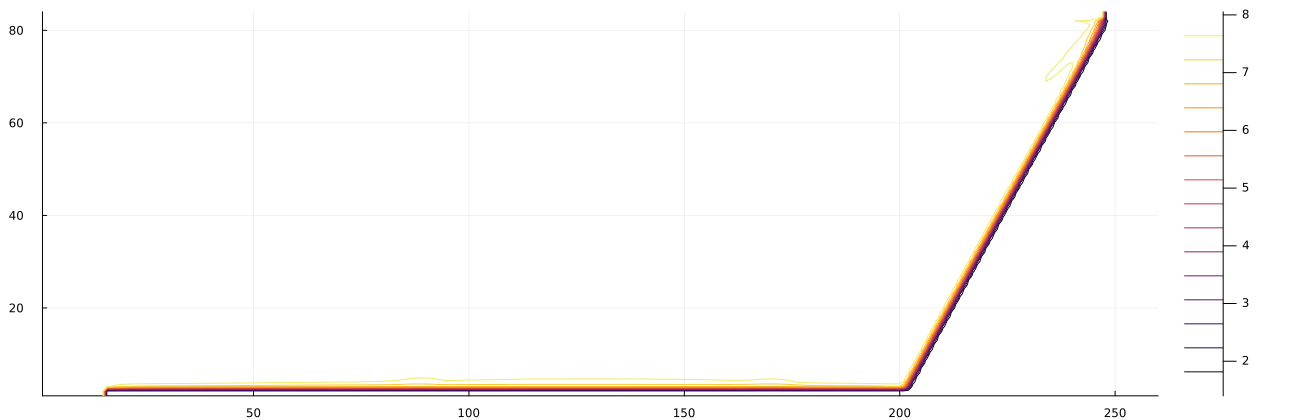

In [6]:
show_double_Mach(fvm)